<a href="https://colab.research.google.com/github/Shibu09-tech/AI-ML-Projects-and-Notes/blob/main/Lab1_Mileage_Prediction/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mileage Prediction using Machine Learning

---



## Objective
The goal of this project is to predict vehicle mileage using machine learning techniques based on automobile features such as horsepower, weight, and cylinders.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [ ]:
#loading the dataset
df=pd.read_csv("/content/auto-mpg.csv")

In [ ]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [ ]:
#understanding the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [ ]:
#changing the datatype of horsepower from object
df['horsepower']=pd.to_numeric(df['horsepower'],errors='coerce')

In [ ]:
#updated datatype to verify
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [ ]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [ ]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [ ]:
#checking the missing values
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model year,0
origin,0
car name,0


# **Handle Missing Values**

In [ ]:
df['horsepower'].fillna(df['horsepower'].mean(),inplace=True)

/tmp/ipykernel_2195/1428615506.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].mean(),inplace=True)


In [ ]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


# **Removing the unnecessary columns**

'car name' is text and not useful for basic prediction

In [ ]:
df=df.drop('car name',axis=1)

In [ ]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


# Understanding Relationships Between Features

Correlation matrix








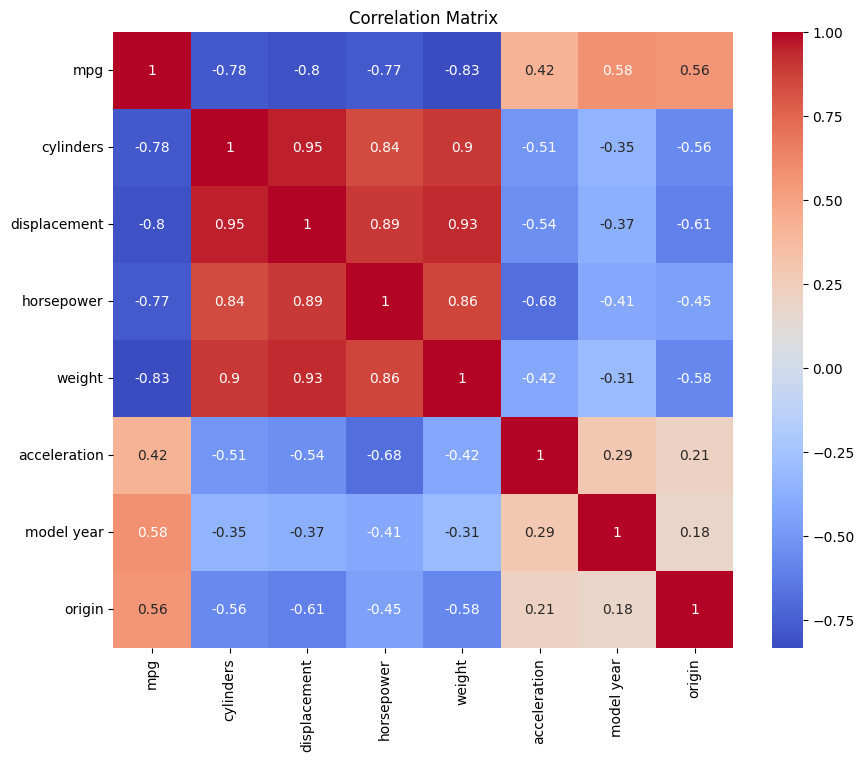

In [ ]:
correlation=df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Visualize Relationships

MPG vs **Weight**

As weight increases, mpg decreases.

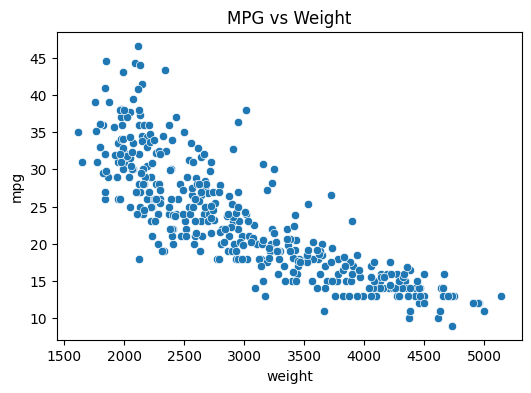

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='weight',y='mpg',data=df)
plt.title('MPG vs Weight')
plt.show()

**Horsepower vs MPG**





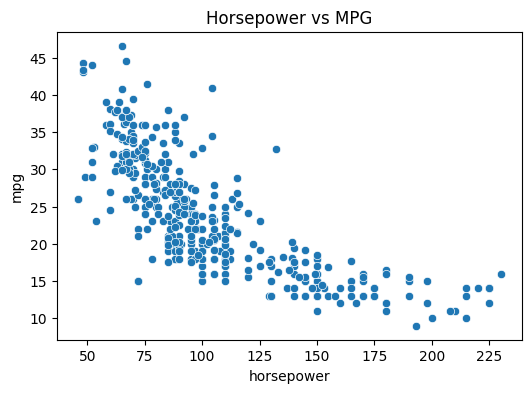

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='horsepower', y='mpg', data=df)
plt.title('Horsepower vs MPG')
plt.show()

**Cylinders vs MPG**

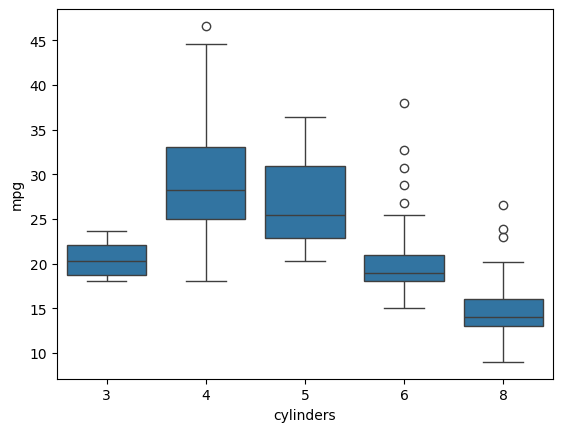

In [ ]:
sns.boxplot(x='cylinders', y='mpg', data=df)
plt.show()

**Model year Vs MPG**

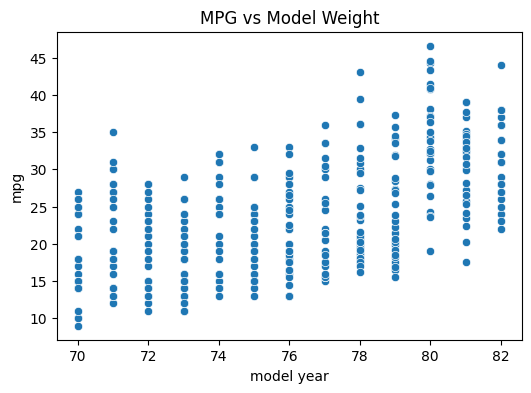

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='model year',y='mpg',data=df)
plt.title('MPG vs Model Weight')
plt.show()

# **Feature Selection**

Choosing important columns for training.

In [ ]:
#Important features
X = df[['cylinders', 'displacement', 'horsepower',
          'weight', 'acceleration', 'model year', 'origin']]

In [ ]:
#target
y=df['mpg']

# **Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Machine Learning Model**

In [ ]:
model= LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

        Feature  Coefficient
0     cylinders    -0.154180
1  displacement     0.013997
2    horsepower    -0.011798
3        weight    -0.006775
4  acceleration     0.074889
5    model year     0.796479
6        origin     1.313313


In [ ]:
y_pred=model.predict(X_test)

# **Compare Actual vs Predicted**

In [ ]:
comparison = pd.DataFrame({
    'Actual MPG': y_test,
    'Predicted MPG': y_pred
})

print(comparison)

     Actual MPG  Predicted MPG
198        33.0      32.863457
396        28.0      29.581302
33         19.0      21.351261
208        13.0      16.805687
93         14.0      12.501362
..          ...            ...
249        19.9      22.126732
225        17.5      20.515878
367        28.0      29.573530
175        29.0      29.322390
285        17.0      20.091405

[80 rows x 2 columns]


# **Model Performance**

R2 **Score**

In [ ]:
r2=r2_score(y_test,y_pred)
print("R2 Score:",r2)

R2 Score: 0.8475731044779433


Mean Absolute **Error**

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print('MAE:', mae)

MAE: 2.253388405931761


**Mean Squared Error**

Lower value = better model.

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print('MSE:', mse)

MSE: 8.195452104073789


# **Visualization of Predictions**


If points are close to straight line the Model is performing well.

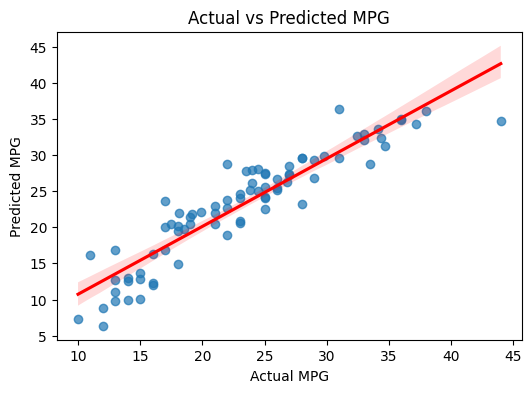

In [ ]:
plt.figure(figsize=(6,4))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'})
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs Predicted MPG')
plt.show()

# **Predicting Output**

Patterns learned during training.
Then calculates predicted mileage.

In [ ]:
new_car_data=[[4, 140, 90, 2400, 15, 82, 1]]

predicted_mpg = model.predict(new_car_data)
print('Predicted MPG:', predicted_mpg[0])

Predicted MPG: 30.986294754982957


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# **Conclusion**

In this lab, we implemented a Linear Regression model to predict car mileage (MPG) using the Auto MPG dataset. We performed data preprocessing, analyzed feature relationships, trained the model, and evaluated its performance. The model successfully predicted mileage based on car features like weight, horsepower, and cylinders.